In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f"{df.shape[0]} emprunteurs, {df.shape[1]} colonnes")
df.head()

32581 emprunteurs, 12 colonnes


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
print(" Valeurs manquantes:")
print(df.isnull().sum())
print(f"\nTotal : {df.isnull().sum().sum()} valeurs manquantes")

 Valeurs manquantes:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Total : 4011 valeurs manquantes


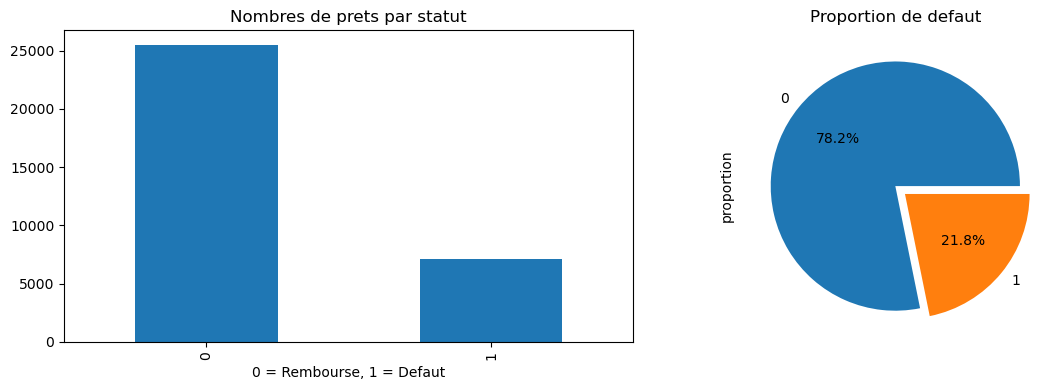

In [6]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Nombres de prets par statut')
axes[0].set_xlabel('0 = Rembourse, 1 = Defaut')
df ['loan_status'].value_counts(normalize=True).plot(kind='pie',
                                                     autopct='%1.1f%%',
                                                     ax=axes[1],
                                                     explode=(0,0.1))
axes[1].set_title('Proportion de defaut')
plt.tight_layout()
#plt.savefig('distibution_cible.png')
plt.show()

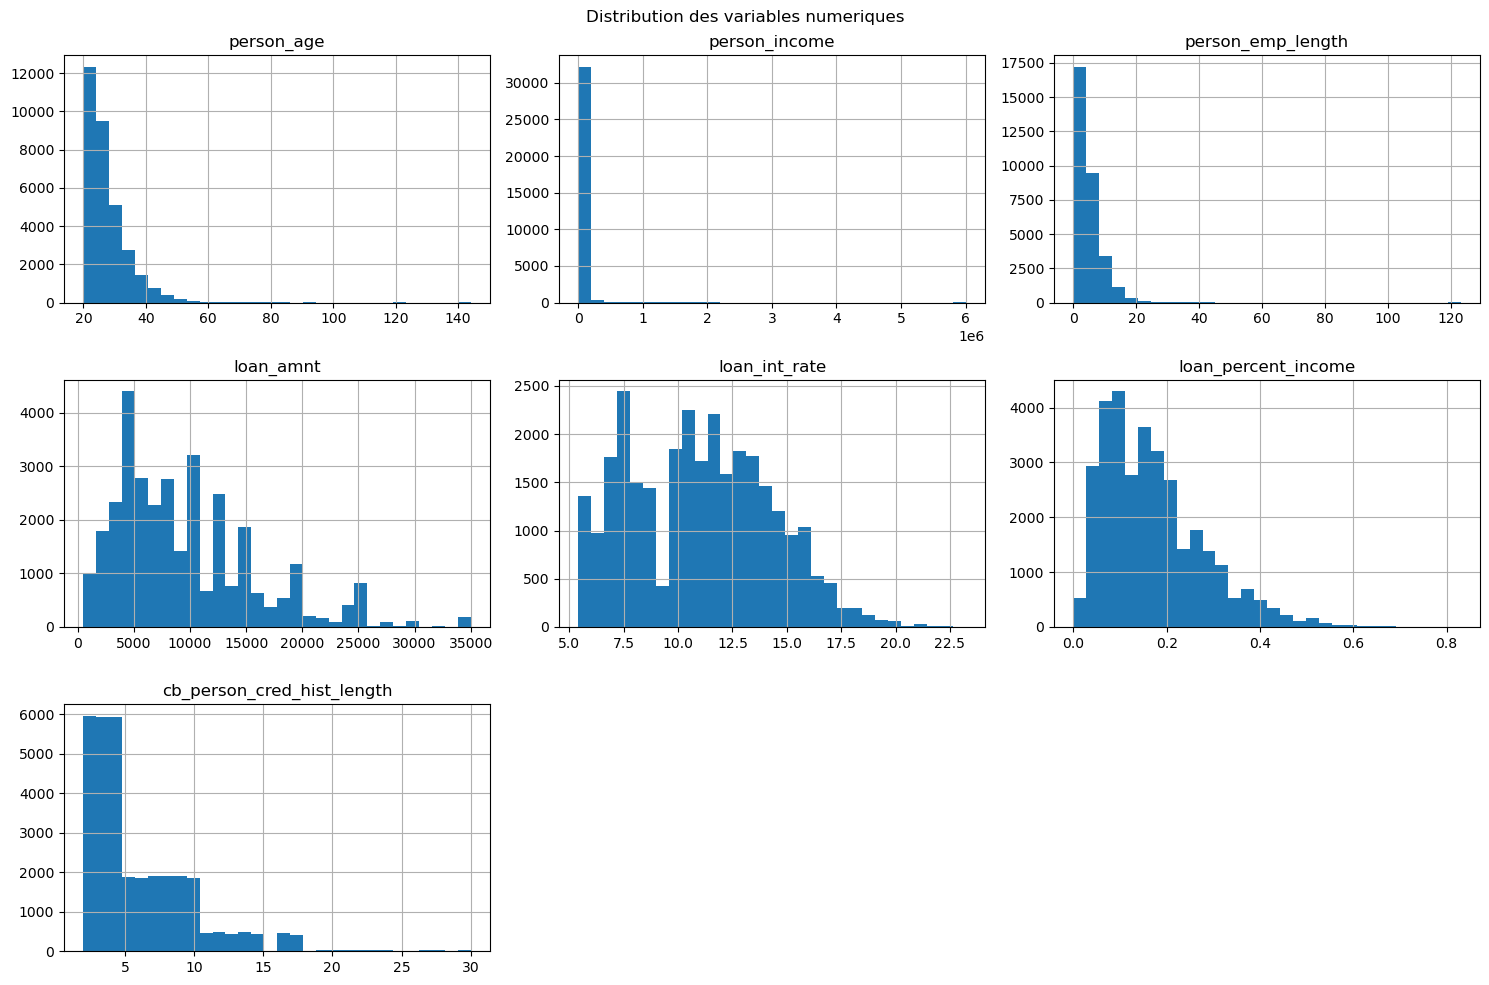

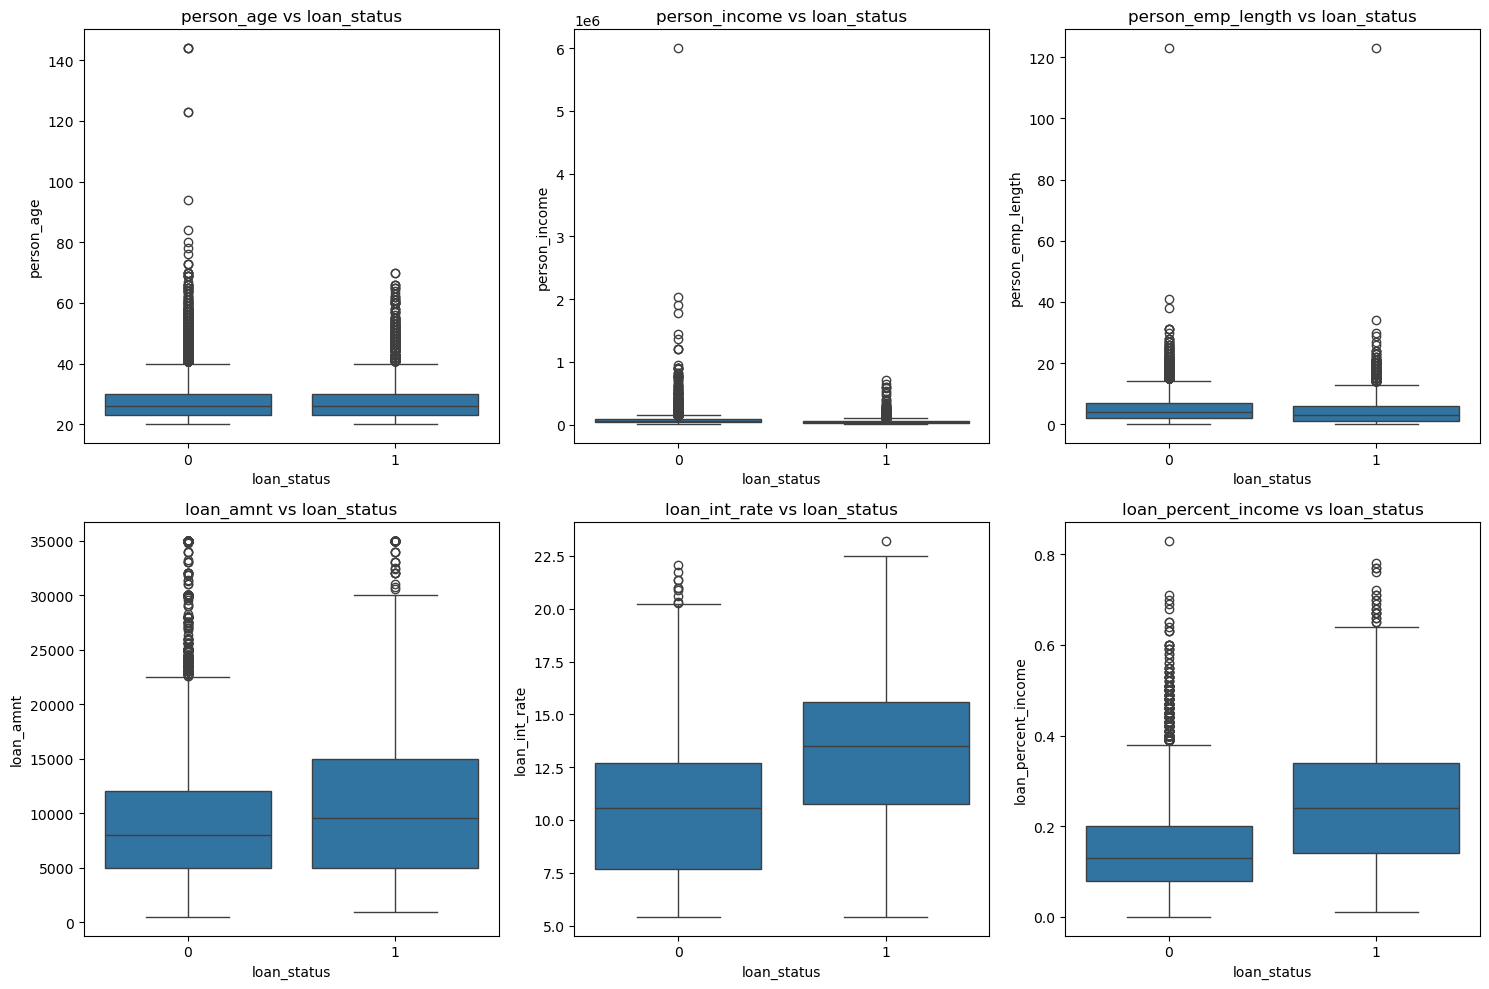

In [10]:
# Analyse des variables numeriques
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

df[numeric_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Distribution des variables numeriques')
plt.tight_layout()
plt.show()

# Boxplots par statut
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:6]):
    sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs loan_status')
plt.tight_layout()
plt.show()

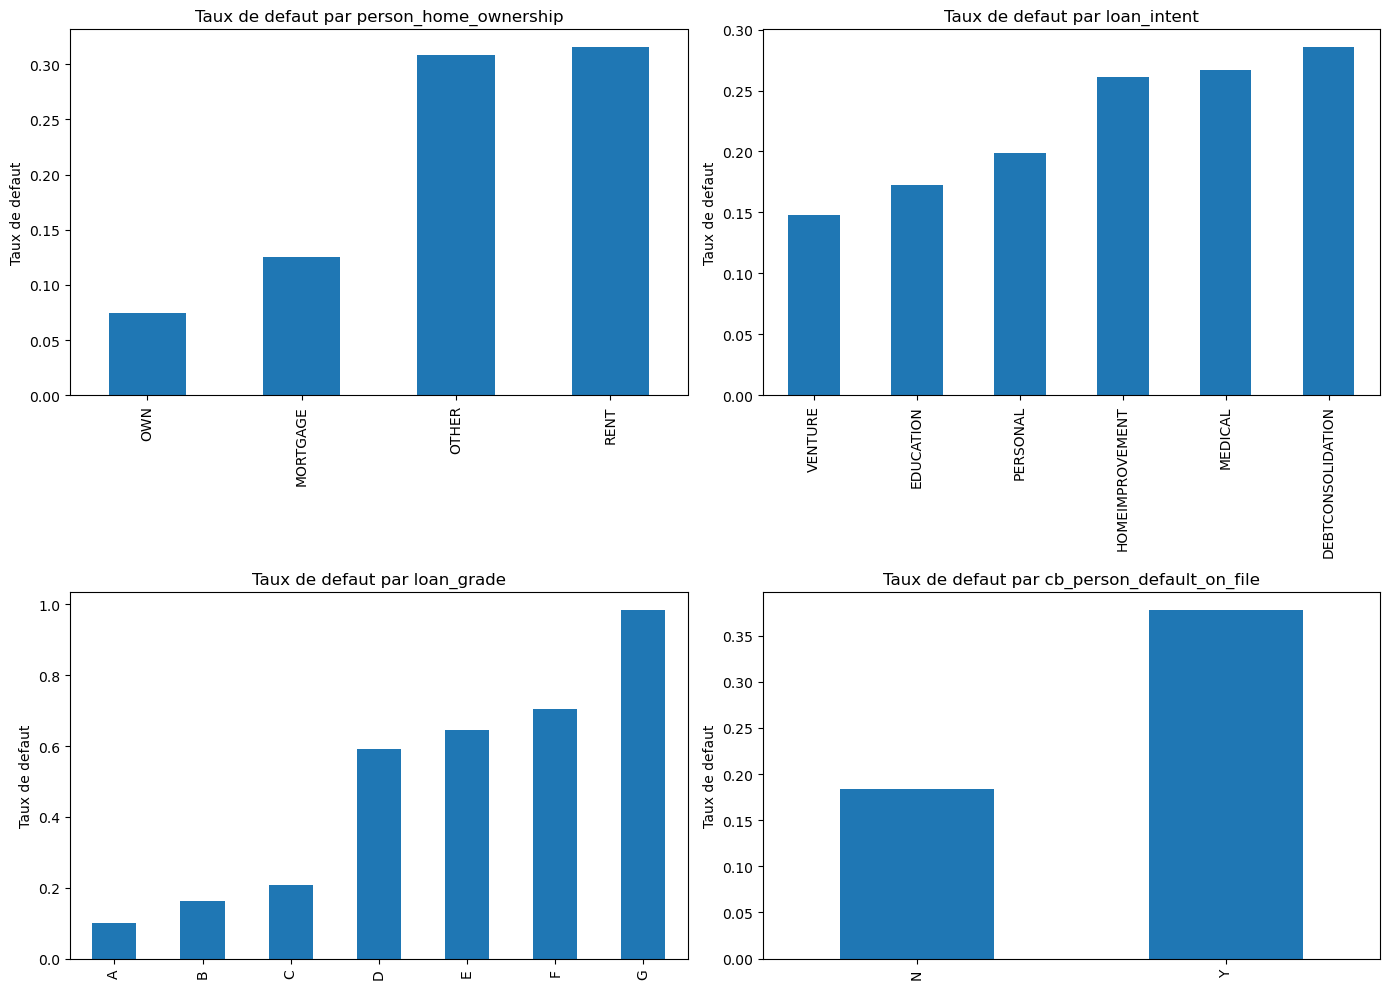

In [11]:
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    df.groupby(col)['loan_status'].mean().sort_values().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Taux de defaut par {col}')
    axes[i].set_ylabel('Taux de defaut')
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

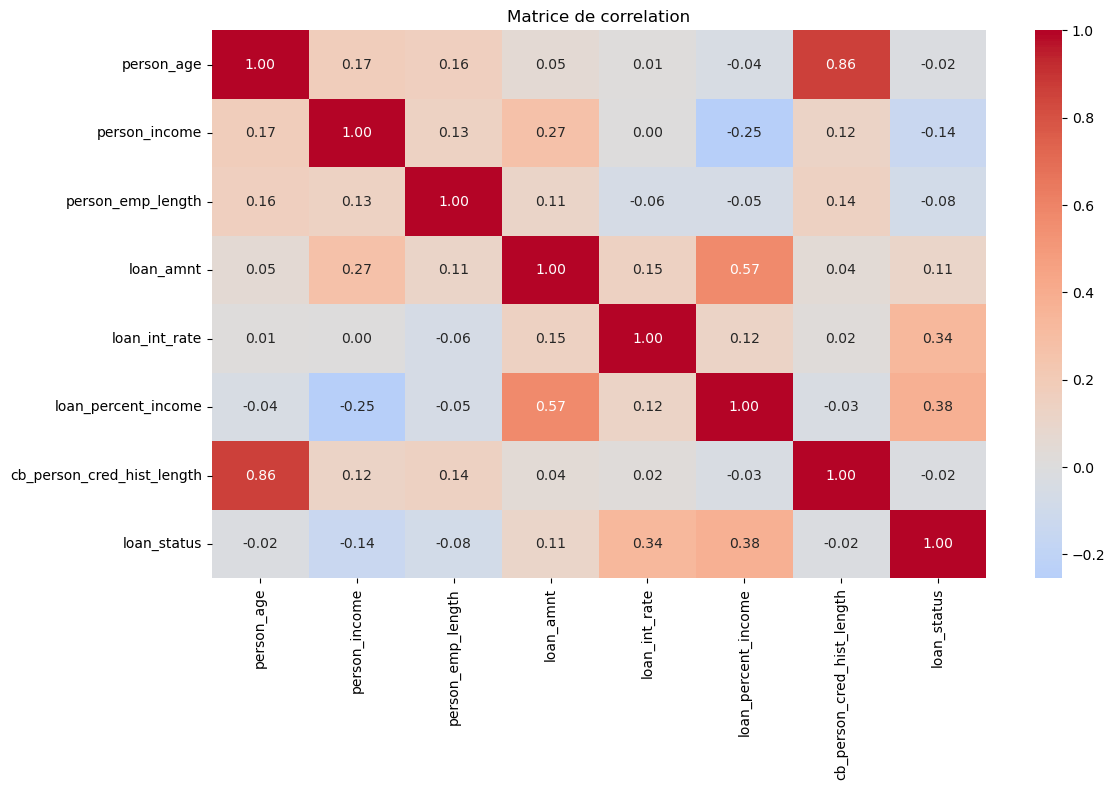

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols + ['loan_status']].corr(), 
             annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

In [14]:
# 9. SYNTHÈSE DES DÉCOUVERTES
# ----------------------------
print("="*60)
print("📝 SYNTHÈSE DE L'ANALYSE EXPLORATOIRE")
print("="*60)
print("""
1. DÉSÉQUILIBRE DES CLASSES :
   - Environ 22% des prêts sont en défaut
   - Problème de classification déséquilibré

2. FACTEURS DE RISQUE IDENTIFIÉS :
   - Loan Grade : les notes D, E, F ont plus de défauts
   - Loan Intent : les prêts personnels et d'éducation ont plus de risques
   - Revenu : les faibles revenus sont plus à risque
   - Historique de défaut : les personnes ayant déjà fait défaut sont plus à risque

3. CORRÉLATIONS FORTES :
   - loan_percent_income corrélé positivement avec loan_status
   - loan_int_rate corrélé positivement avec loan_status
   - loan_grade (plus mauvais grade = plus de risque)

4. PROCHAINES ÉTAPES :
   - Traiter les valeurs manquantes (loan_int_rate, person_emp_length)
   - Encoder les variables catégorielles
   - Construire un modèle de classification
   - Évaluer avec F1-score et ROC-AUC
""")

📝 SYNTHÈSE DE L'ANALYSE EXPLORATOIRE

1. DÉSÉQUILIBRE DES CLASSES :
   - Environ 22% des prêts sont en défaut
   - Problème de classification déséquilibré

2. FACTEURS DE RISQUE IDENTIFIÉS :
   - Loan Grade : les notes D, E, F ont plus de défauts
   - Loan Intent : les prêts personnels et d'éducation ont plus de risques
   - Revenu : les faibles revenus sont plus à risque
   - Historique de défaut : les personnes ayant déjà fait défaut sont plus à risque

3. CORRÉLATIONS FORTES :
   - loan_percent_income corrélé positivement avec loan_status
   - loan_int_rate corrélé positivement avec loan_status
   - loan_grade (plus mauvais grade = plus de risque)

4. PROCHAINES ÉTAPES :
   - Traiter les valeurs manquantes (loan_int_rate, person_emp_length)
   - Encoder les variables catégorielles
   - Construire un modèle de classification
   - Évaluer avec F1-score et ROC-AUC

